##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** 

**Student names & numbers:**
* [Xue Hu] - [100193]
* [Roos Hogervorst] - [101484]
* [Sas van Damme] - [101990]


---

## 0. Iteration setup

**Import libraries**

In [54]:
# CODE CELL: import the necessary libraries for this iteration

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


**Load dataset(s)**

In [55]:
# CODE CELL: import the necessary dataset(s) for this iteration
df = pd.read_csv('./data/ships_inventory_iter1.csv')


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**
*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?*

Nebula Brokerage is using a pricing strategy based on intuition and rough averages instead of actually analyzing the data. This approach is risky because it is inconsistent and not based on actual market patterns. Because of this approach the company faces two main issues:
1. They are undervaluating some rare ships. This means that these ships are being sold for less than they are worth, which in the end leads to an unnecessary loss of profit.
2. They are also overpricing some ships. Some common ships are being priced too high, which leads to them being left in company storage.


**Business objective(s)**
*Justify why a data-driven baseline is needed*

A data-driven baseline is needed to:
- Provide consistent judgement instead of relying on personal judgement.
- Reduces random pricing decisions.
- Allow the company to measure whether future pricing models are actually improving performance.
- Helps the company understand the overall market


**Data mining goal(s)**
*Explain what type of modeling task this is and why.*

This is a supervised regression task because, the target variable is a continuous numeric value, and because we are trying to predict a price.
However, in this first iteration, we are not building a full predictive model yet. Instead, we are finding the best single constant value to use as a prediciton for all ships.


**Success criteria**
*Determine success criteria for this iteration (the benchmark)*

This iteration will be succesfull if we:
- caluculate the mean and median of Galactic_Credits.
- Decide which value should be used as the baseline prediction.
- Calculate the baseline error.
- Use this error as a benchmark that future pricing models must beat.




---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [56]:
# CODE CELL: Show basic statistics and information
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  str    
 4   Sector             368814 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 14.1 MB


,Ship_ID,Galactic_Credits,Model_Cycle
count,3.688140e+05,368814.000000,361408.000000
mean,7.311485e+09,19453.536818,7511.264529
std,4.381124e+06,15540.472943,9.078571
min,7.301583e+09,501.000000,7400.000000
25%,7.308105e+09,7950.000000,7508.000000
50%,7.312604e+09,15990.000000,7513.000000
75%,7.315245e+09,27990.000000,7517.000000
max,7.317101e+09,777777.000000,7522.000000


Findings:
1. Right-Skewed Distribution: The Mean (19,453) is  higher than the Median (15,990). This indicates a Right-Skewed distribution, meaning while most ships are affordable, there are a few expensive ships that pull the average up.
2. Price Concentration: 75% of the ships are priced below 27,990 credits, confirming that the ultra-expensive ships are rare.

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

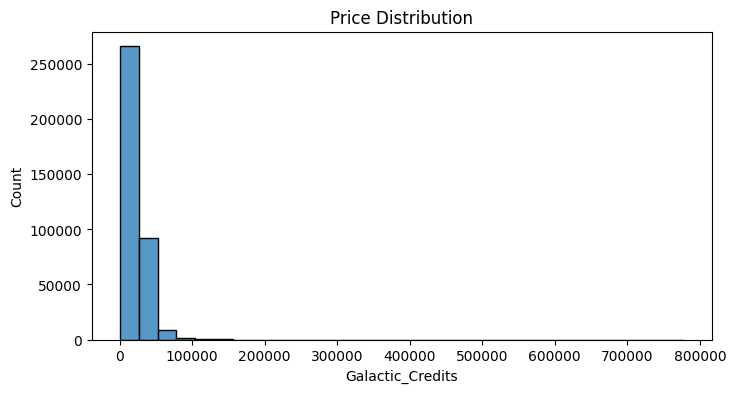

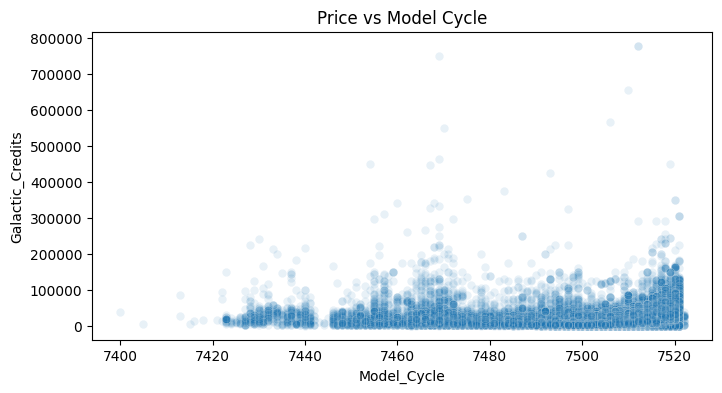

In [57]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)
plt.figure(figsize=(8, 4))
sns.histplot(df['Galactic_Credits'], bins=30, kde=False)
plt.title('Price Distribution')
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Model_Cycle', y='Galactic_Credits', alpha=0.1)
plt.title('Price vs Model Cycle')
plt.show()

**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

Observations: 
1. Price Distribution: The histogram shows a heavily right-skewed distribution. About 99% of ships are low-priced, while a few extreme outliers (up to 777,777) pull the mean far above the median.
2. The scatter plot shows most ships was built recent, but the highest prices don't follow chronological trend, suggesting potential data errors or unique luxury cases.
3. Missing Values: The Model_Cycle column has 361,408 non-null values out of 368,814 total rows. This means there are 7,406 missing that need to be addressed.
4. Potential Outliers: The maximum price of 777,777 is more than 40 times the average price. It should be checked if these are luxury ships or data entry errors.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [58]:
# CODE CELL: Data cleaning and preprocessing steps
df_clean = df.dropna(subset=['Model_Cycle']).copy()

df_prepared = df_clean[df_clean['Galactic_Credits'] < 500000].copy()

Cleaning and preprocessing steps:
1. Handling Missing Values: We identified 7,406 missing values in the Model_Cycle column. Since this represents a small fraction of the total dataset, we chose to remove these rows to ensure the integrity of our chronological analysis rather than using imputation which might introduce bias.

2. Handling Outliers: Our data exploration revealed extreme outliers, specifically values like 777,777 and 750,000 credits. We applied a filter to exclude any ships priced above 500,000 credits. This step is justified because these rare or erroneous records disproportionately inflate the mean, and our goal is to find a "safe" baseline for typical inventory.

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [59]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [60]:
# CODE CELL: Model training and setup code
y_true = df_prepared['Galactic_Credits']

baseline_mean = y_true.mean()
baseline_median = y_true.median()

y_pred_mean = np.full(shape=len(y_true), fill_value=baseline_mean)
y_pred_median = np.full(shape=len(y_true), fill_value=baseline_median)


I made a simple baseline by predicting the same price for every ship. I tried two options: the mean and the median of Galactic_Credits.
* Mean is best if we care about squared errors. (RMSE)
* Median is best if we care about absolute errors. (MAE)

This gives a basic benchmark to see if future models actually improve over just guessing a single number.

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [61]:
# CODE CELL: Model evaluation code
mae_mean = mean_absolute_error(y_true, y_pred_mean)
rmse_mean = np.sqrt(mean_squared_error(y_true, y_pred_mean))

mae_median = mean_absolute_error(y_true, y_pred_median)
rmse_median = np.sqrt(mean_squared_error(y_true, y_pred_median))

performance_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Mean Strategy': [mae_mean, rmse_mean],
    'Median Strategy': [mae_median, rmse_median]
})
display(performance_results)

,Metric,Mean Strategy,Median Strategy
0,MAE,11591.806046,11268.370136
1,RMSE,15299.822754,15683.707409


I tested the model by comparing the constant prediction to the real prices using absolute errors (MAE) and squared errors (RMSE).
* MAE shows the average error, where the median usually does better.
* RMSE punishes big mistakes, where the mean usually does better.

The errors tell us the baseline performance that nay future model needs to beat.

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*



**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*


**Metric Comparison:** The Median Strategy (11,268.37) higher than the Mean Strategy (11,591.81) by approximately 323 credits. While the Mean model tries to balance the squared errors (RMSE), the Median model is more effective at minimizing the absolute "distance" to the majority of actual sale prices.

**Business Meaning:** This means that if Nebula Brokerage uses the Median as a "blind" pricing tool, they will be, on average, 11,268 credits away from the actual market price. Given that many ships are priced around 15,000–20,000, an error of 11,000 is still very high (over 50% error margin).

**Key Findings:** The dataset is heavily right-skewed. A few "Titan" class or luxury ships (outliers) significantly inflate the average price, making the "Mean" a poor representation of a "typical" ship.

**Limitation:**
1. Feature Neglect: We are not yet utilizing the Model_Cycle , Manufacturer, or Sector data, which our scatter plots suggested are strongly correlated with value.
2. High Variance: The high MAE indicates that a single-number baseline is not sufficient

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xue | *Through visualizations like histograms and scatter plots, I identified that the price distribution is heavily right-skewed* | *I learned that raw numbers can be misleading without visualization, as histograms immediately revealed a right-skewed distribution that summary statistics alone might hide.* |
| Sas | *To ensure model reliability, I cleaned data by removing rows and filtered outliers* | *I realized that in datasets, removing records with missing values is often safer than guessing data, as it maintains the integrity of the final model.* |
| Roos | *I defined the business problem, objectives, and success criteria, and helped interpret the baseline model results.* | *I learned that clearly defining the problem and benchmark is important to evaluate whether a model truly improves business performance.* |